Import Modules

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay )
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, BatchNormalization, Dropout, Flatten, Dense )
from tensorflow.keras.optimizers import Adam

import joblib

In [3]:
phone_acc = pd.read_csv(r"/content/drive/MyDrive/Phones_accelerometer.csv")
phone_gyro = pd.read_csv(r"/content/drive/MyDrive/Phones_gyroscope.csv")
watch_acc = pd.read_csv(r"/content/drive/MyDrive/Watch_accelerometer.csv")
watch_gyro = pd.read_csv(r"/content/drive/MyDrive/Watch_gyroscope.csv")

# **Data Cleaning**

In [4]:
for df in [phone_acc, phone_gyro, watch_acc, watch_gyro]:
    df["Arrival_Time"] = pd.to_datetime(df["Arrival_Time"])
    df.drop_duplicates(inplace = True)
    df.dropna(inplace = True)
    print(df.shape)

cols = ["Arrival_Time", "User", "x", "y", "z"]

phone_acc = phone_acc.rename(columns = {"x": "pa_x", "y": "pa_y", "z": "pa_z"}).sort_values("Arrival_Time")
phone_gyro = phone_gyro[cols].rename(columns = {"x": "pg_x", "y": "pg_y", "z": "pg_z"}).sort_values("Arrival_Time")
watch_acc = watch_acc[cols].rename(columns = {"x": "wa_x", "y": "wa_y", "z": "wa_z"}).sort_values("Arrival_Time")
watch_gyro = watch_gyro[cols].rename(columns = {"x": "wg_x", "y": "wg_y", "z": "wg_z"}).sort_values("Arrival_Time")

(11279275, 10)
(12063005, 10)
(3020605, 10)
(2735002, 10)


In [5]:
cols = ["User", "Activity"]

df = pd.merge_asof(phone_acc, phone_gyro, on = "Arrival_Time", by = "User", direction = "nearest", tolerance = pd.Timedelta("1s"))
df = pd.merge_asof(df, watch_acc, on = "Arrival_Time", by = "User", direction = "nearest", tolerance = pd.Timedelta("1s"))
df = pd.merge_asof(df, watch_gyro, on = "Arrival_Time", by = "User", direction = "nearest", tolerance = pd.Timedelta("1s"))

df.dropna(inplace = True)
df.reset_index(drop = True, inplace = True)

print("Final shape:", df.shape)

Final shape: (11279275, 19)


In [6]:
print(df["gt"].value_counts())

gt
walk          2192401
sit           1991919
stand         1851492
bike          1845557
stairsup      1782010
stairsdown    1615896
Name: count, dtype: int64


In [7]:
# Normalize values

scaler = StandardScaler()

features = [
    "pa_x","pa_y","pa_z",
    "pg_x","pg_y","pg_z",
    "wa_x","wa_y","wa_z",
    "wg_x","wg_y","wg_z"
]

df[features] = scaler.fit_transform(df[features])

In [8]:
# Encode values

encoder = LabelEncoder()

df["Activity"] = encoder.fit_transform(df["gt"])

print(encoder.classes_)

['bike' 'sit' 'stairsdown' 'stairsup' 'stand' 'walk']


In [9]:
# Create Sliding Windows

Window, Step = 128, 64

X = []
y = []

for user, temp in df.groupby("User"):
    temp = temp.sort_values("Arrival_Time")

    values = temp[features].values
    labels = temp["Activity"].values

    windows = (len(values) - Window) // Step + 1
    if windows <= 0:
        continue

    for i in range(windows):
        start = i * Step
        window_labels = labels[start : start + Window]

        if window_labels[0] == window_labels[-1] and len(np.unique(window_labels)) == 1:
            X.append(values[start : start + Window])
            y.append(window_labels[0])

X = np.array(X)
y = np.array(y)

X, y = shuffle(X, y, random_state = 42)

print(X.shape)
print(y.shape)

(175986, 128, 12)
(175986,)


In [10]:
num_classes = len(encoder.classes_)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y, shuffle = True)

In [12]:
df.to_feather("HHAR_Merged.feather")

# Creating CNN Model

In [13]:
model = Sequential([
    tf.keras.Input(shape = (128, 12)),
    Conv1D(filters = 64, kernel_size = 5, activation = 'relu', padding = 'same'),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    Dropout(0.3),

    Conv1D(filters = 128, kernel_size = 5, activation = 'relu', padding = 'same'),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    Dropout(0.3),

    Conv1D(filters = 256, kernel_size = 3, activation = 'relu', padding = 'same'),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    Dropout(0.3),

    Flatten(),

    Dense(256, activation = 'relu'),
    Dropout(0.5),

    Dense(128, activation = 'relu'),
    Dropout(0.5),

    Dense(num_classes, activation = 'softmax')
])

In [14]:
model.compile(optimizer = Adam(learning_rate = 0.001), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,227,846 (4.68 MB)

 Trainable params: 1,226,950 (4.68 MB)

 Non-trainable params: 896 (3.50 KB)

In [15]:
early_stop = EarlyStopping(monitor = "val_loss", patience = 5, restore_best_weights = True)

reduce_lr = ReduceLROnPlateau(monitor = "val_loss", factor = 0.5, patience = 2, verbose = 1)

checkpoint = ModelCheckpoint("best_hhar.keras", monitor = "val_accuracy", save_best_only = True, mode = "max")

history = model.fit(X_train, y_train, epochs = 15, batch_size = 64, validation_data = (X_test, y_test), callbacks = [early_stop, reduce_lr, checkpoint])

Epoch 1/15
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.8118 - loss: 0.5189 - val_accuracy: 0.8832 - val_loss: 0.3105 - learning_rate: 0.0010
Epoch 2/15
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9113 - loss: 0.2728 - val_accuracy: 0.9331 - val_loss: 0.1865 - learning_rate: 0.0010
Epoch 3/15
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9325 - loss: 0.2149 - val_accuracy: 0.9484 - val_loss: 0.1444 - learning_rate: 0.0010
Epoch 4/15
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9442 - loss: 0.1826 - val_accuracy: 0.9598 - val_loss: 0.1169 - learning_rate: 0.0010
Epoch 5/15
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9495 - loss: 0.1632 - val_accuracy: 0.9630 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 6/15
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9540 - loss: 0.1519 - val_accuracy: 0.9678 - val_loss: 0.0954 - learning_rate: 0.0010
Epoch 7/15
2200/2200 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9797 - loss: 0.0635
Accuracy: 0.9796863198280334


In [17]:
pred = model.predict(X_test)

pred = np.argmax(pred, axis = 1)

true = y_test

1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [18]:
print(classification_report(true, pred, target_names = encoder.classes_))

              precision    recall  f1-score   support

        bike       0.99      0.99      0.99      5764
         sit       1.00      1.00      1.00      6221
  stairsdown       0.96      0.94      0.95      5031
    stairsup       0.95      0.97      0.96      5551
       stand       1.00      1.00      1.00      5783
        walk       0.97      0.97      0.97      6848

    accuracy                           0.98     35198
   macro avg       0.98      0.98      0.98     35198
weighted avg       0.98      0.98      0.98     35198



Plot

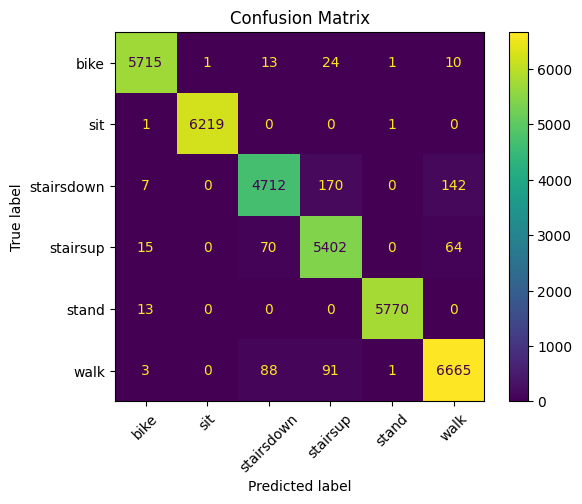

In [19]:
ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(true, pred), display_labels = encoder.classes_).plot(xticks_rotation = 45)
plt.title("Confusion Matrix")
plt.show()

From the classification report and the Confusion matrix, we can see that most of the categories have been correctly identified with few drawbacks in stairsup and stairdown.

Additional files (saving)

In [20]:
model.save("HHAR_CNN.keras")

In [21]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [22]:
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']

In [23]:
# Create demo windows

indices = np.random.choice(len(X), 300, replace = False)

np.save("demo_windows.npy", X[indices])

🎯 Created 'demo_windows.npy' successfully!
